In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [2]:
def import_excel(name: str, sheet=0, skip_rows=2, usecolumns='A,B,G:J', channel_start=1596, channel_end=1896):
    dataframe = pd.read_excel(name, sheet_name=sheet, skiprows=skip_rows, usecols=usecolumns)
    
    return dataframe[ (dataframe['Canal'] >= channel_start) & (dataframe['Canal'] <= channel_end) ]

def process_replicas(dataframe, column_name='replica N corregido', nreplicas=3, plot='no'):
    name_cols = [column_name.replace('N', str(i+1)) for i in range(nreplicas)]
    
    data = dataframe[name_cols].to_numpy()
    energy = dataframe['Energía keV'].to_numpy()

    counts = data.mean(axis=1)
    
    data_norm = data / data.max(axis=0)
    counts_norm = data_norm.mean(axis=1)

    if plot=='yes':
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        colors = plt.cm.tab10(np.linspace(0, 1, nreplicas))

        config = [
            (data, counts, 'Counts', 'Unnormalized', axs[0]),
            (data_norm, counts_norm, 'Normalized Counts', 'Normalized', axs[1])
        ]

        for d_matrix, d_mean, ylabel, title, ax in config:
            for i in range(nreplicas):
                ax.plot(energy, d_matrix[:, i], label=name_cols[i], alpha=0.7)
            
            ax.plot(energy, d_mean, color='black', lw=1, label='Mean')
            ax.set_xlabel('keV')
            ax.set_ylabel(ylabel)
            ax.set_title(title)
            ax.grid(True, linestyle='--', alpha=0.6)
            ax.legend()

        plt.tight_layout()
        plt.show()

    return energy, counts, counts_norm

def find_initial_rayleigh(ENERGY, COUNTS, PRINT='no'):
    maxRayleighIntensity = max(COUNTS)
    maxRayleighIntensity_idx = np.where(COUNTS == maxRayleighIntensity)[0][0]
    centerRayleigh = ENERGY[maxRayleighIntensity_idx] 

    if PRINT=='yes':
        print(f"Maximum Rayleigh intensity: {maxRayleighIntensity}")
        print(f"Maximum energy at Rayleigh intensity: {centerRayleigh} keV")
    
    return centerRayleigh, maxRayleighIntensity

# Importing spreadsheets

In [3]:
file_initial = 'Muestras_de_coco_inicial'
sheet_initial = 'CoS_1_inicial'

file_duplicate = 'Muestras_de_coco_duplicado'
sheet_duplicate = 'CoS_1_duplicado'

file_triplicate = 'Muestras_de_coco_triplicado'
sheet_triplicate = 'CoS_1_triplicado'

# Original
df = import_excel(f'{file_initial}.xlsx', sheet=sheet_initial, 
                    skip_rows=2, usecolumns='A,B,G:J', 
                    channel_start=1596, channel_end=1896)

# Duplicate
df_dup = import_excel(f'{file_duplicate}.xlsx', sheet=sheet_duplicate, 
                    skip_rows=2, usecolumns='A,B,G:J', 
                    channel_start=1596, channel_end=1896)

# Triplicate
df_tri = import_excel(f'{file_triplicate}.xlsx', sheet=sheet_triplicate, 
                    skip_rows=2, usecolumns='A,B,G:J', 
                    channel_start=1596, channel_end=1896)

name_base = sheet_initial[:6]

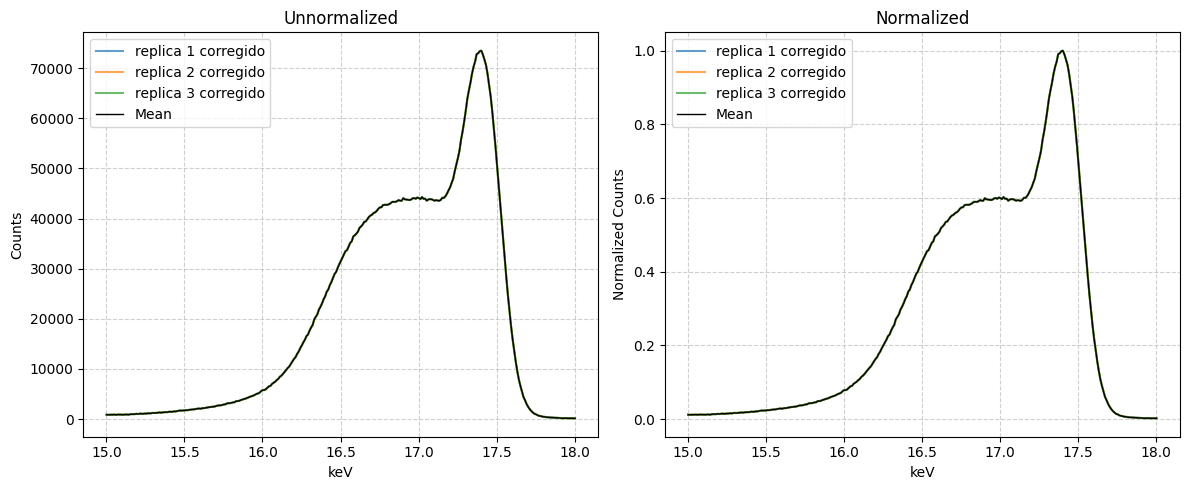

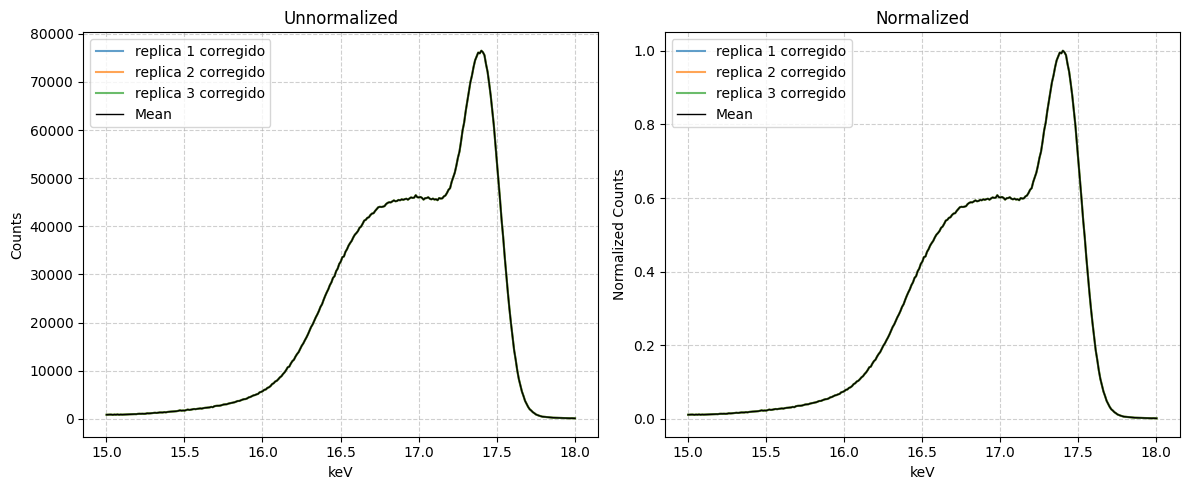

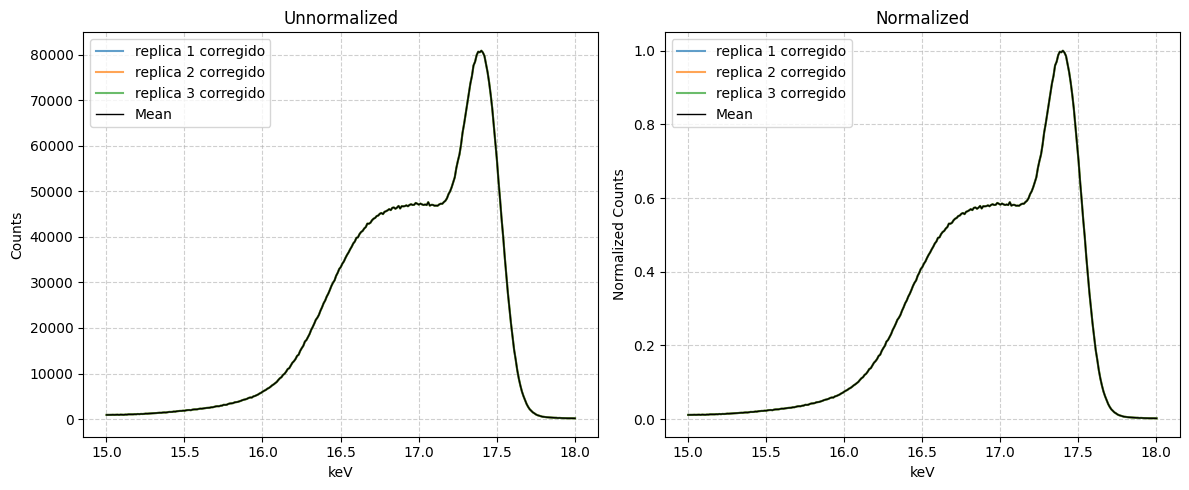

In [4]:
# Original
energy, counts, countsNorm = process_replicas(df, column_name='replica N corregido', 
                                             nreplicas=3, plot='yes')

# Duplicate
energy_dup, counts_dup, countsNorm_dup = process_replicas(df_dup, column_name='replica N corregido', 
                                             nreplicas=3, plot='yes')

# Triplicate
energy_tri, counts_tri, countsNorm_tri = process_replicas(df_tri, column_name='replica N corregido', 
                                             nreplicas=3, plot='yes')

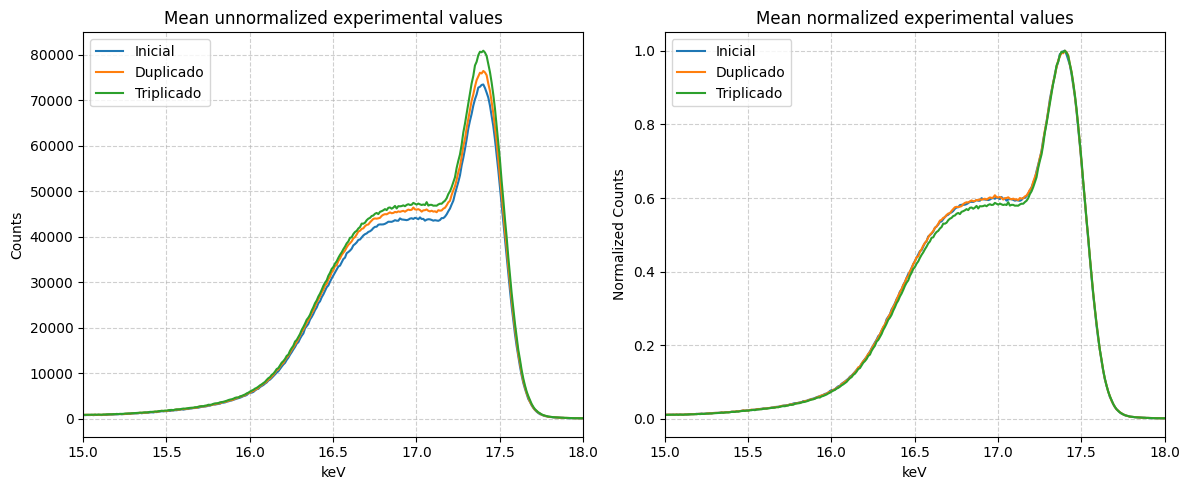

In [5]:
# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].plot(energy, counts, color='tab:blue', label='Inicial')
axs[0].plot(energy_dup, counts_dup, color='tab:orange', label='Duplicado')
axs[0].plot(energy_tri, counts_tri, color='tab:green', label='Triplicado')
axs[0].set_xlabel('keV')
axs[0].set_ylabel('Counts')
axs[0].set_title('Mean unnormalized experimental values')
axs[0].set_xlim(15,18)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend(loc=0)

axs[1].plot(energy, countsNorm, color='tab:blue', label='Inicial')
axs[1].plot(energy_dup, countsNorm_dup, color='tab:orange', label='Duplicado')
axs[1].plot(energy_tri, countsNorm_tri, color='tab:green', label='Triplicado')
axs[1].set_xlabel('keV')
axs[1].set_ylabel('Normalized Counts')
axs[1].set_title('Mean normalized experimental values')
axs[1].set_xlim(15,18)
axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend(loc=0)

plt.tight_layout()

plt.savefig(f'{name_base}_Plot_ExpValue.png', dpi=300, bbox_inches='tight')

plt.show()

# Split-Gaussian
\begin{align*}
F_{i}(E) &= \cases{        
a_{i}\exp\left(-\frac{(E-b_{i})^{2}}{2\sigma_{i,1}^{2}}\right)       & $E \le b_{i}$ \cr
a_{i}\exp\left(-\frac{(E-b_{i})^{2}}{2\sigma_{i,2}^{2}}\right) & $E>b_{i}$ \cr}
\end{align*}


\begin{align*}
V(E)&=\sum_{i}^{N}F_{i}(E) \\
V(E)&=F_{1}(E)+F_{2}(E)
\end{align*}

In [6]:
def split_compton(E, a1, b1, sigma11, sigma12):
    return np.where(
        E <= b1,
        a1 * np.exp(-0.5 * ((E - b1) / sigma11)**2),
        a1 * np.exp(-0.5 * ((E - b1) / sigma12)**2)
    )


def split_rayleigh(E, a2, b2, sigma21, sigma22):
    return np.where(
        E <= b2,
        a2 * np.exp(-0.5 * ((E - b2) / sigma21)**2),
        a2 * np.exp(-0.5 * ((E - b2) / sigma22)**2)
    )


def func_ini(E, a1, b1, sigma11, sigma12, a2, b2, sigma21, sigma22):
    return split_compton(E, a1, b1, sigma11, sigma12) + split_rayleigh(E, a2, b2, sigma21, sigma22)


def func_dup(E, a1, b1, sigma11, sigma12, a2, b2, sigma21, sigma22):
    return split_compton(E, a1, b1, sigma11, sigma12) + split_rayleigh(E, a2, b2, sigma21, sigma22)


def func_tri(E, a1, b1, sigma11, sigma12, a2, b2, sigma21, sigma22):
    return split_compton(E, a1, b1, sigma11, sigma12) + split_rayleigh(E, a2, b2, sigma21, sigma22)


def fit(func, Energy, Counts, IntGuessComp=0.6, CenterGuessComp=16.6):
    centerRay, maxIntRay = find_initial_rayleigh(Energy, Counts)
    # Initial Guess
    Int_comp = IntGuessComp
    Center_comp = CenterGuessComp
    Left_comp = 0.01
    Right_comp = 0.01
    Int_ray = maxIntRay
    Center_ray = centerRay
    Left_ray = 0.01
    Right_ray = 0.01

    initial_guess = [Int_comp, Center_comp, Left_comp, Right_comp, 
                      Int_ray, Center_ray, Left_ray, Right_ray] 

    # Compton Lower Bounds
    InfInt_comp = maxIntRay/6
    InfCenter_comp = 15
    InfLeft_comp = 0.0001
    InfRight_comp = 0.0001
    # Rayleigh Compton Lower Bounds
    InfInt_ray = maxIntRay/2
    InfCenter_ray = 15
    InfLeft_ray = 0.0001
    InfRight_ray = 0.0001
    # Compton Upper Bounds
    SupInt_comp = maxIntRay
    SupCenter_comp = 18
    SupLeft_comp = 4
    SupRight_comp = 4
    # Rayleigh Upper Bounds
    SupInt_ray = maxIntRay
    SupCenter_ray = 18
    SupLeft_ray = 4
    SupRight_ray = 4

    search_bounds = (
        [InfInt_comp, InfCenter_comp, InfLeft_comp, InfRight_comp, 
         InfInt_ray, InfCenter_ray, InfLeft_ray, InfRight_ray], 
        [SupInt_comp, SupCenter_comp, SupLeft_comp, SupRight_comp, 
         SupInt_ray, SupCenter_ray, SupLeft_ray, SupRight_ray] 
    )
    
    popt, pcov = curve_fit(
    func,
    Energy, 
    Counts,
    p0=initial_guess, 
    bounds=search_bounds,
    maxfev=50000
    )
    
    return popt, pcov 

def areas(parameters, PRINT='no'):
    # parameters = [a1, b1, sigma11 (left), sigma12 (right), a2, b2, sigma21 (left), sigma22 (right)]
    areaComp = parameters[0]*(parameters[2]+parameters[3])*0.5
    areaRay = parameters[4]*(parameters[6]+parameters[7])*0.5
    areaCR = areaComp/areaRay
    
    if PRINT=='yes':
        print(f"Compton Area: {areaComp}")
        print(f"Rayleigh Area: {areaRay}")
        print(f"Ratio Compton/Rayleigh: {areaCR}")
    return areaCR, areaComp, areaRay

def metrics(Func, Params, Energy, Counts PRINT='no'):
    N = len(Counts) 
    y_hat = Func(Energy, *Params) 
    res = Counts-y_hat 

    ss_res = np.sum(res**2) 
    ss_tot = np.sum((Counts - np.mean(Counts))**2)
    r2 = 1 - (ss_res / ss_tot)

    MSE = np.sum(res**2)/N
    RMSE = np.sqrt(MSE) 
    
    if PRINT=='yes':
        print(f"There are {N} data points.")
        print(f"Mean Squared Error: {MSE}")
        print(f"Root Mean Square Error: {RMSE}")
        
    return MSE, RMSE, r2

# Curve fitting

In [7]:
# Compton-Rayleigh
# params = [a1, b1, sigma11 (left), sigma12 (right), a2, b2, sigma21 (left), sigma22 (right)]
params_ini, pcov_ini = fit(func_ini, energy, countsNorm, IntGuessComp=0.6, CenterGuessComp=16.6)
params_dup, pcov_dup = fit(func_dup, energy_dup, countsNorm_dup, IntGuessComp=0.6, CenterGuessComp=16.6)
params_tri, pcov_tri = fit(func_tri, energy_tri, countsNorm_tri, IntGuessComp=0.6, CenterGuessComp=16.6)

# Areas calculations
CR_ini, areaC_ini, areaR_ini = areas(params_ini, PRINT='no')
CR_dup, areaC_dup, areaR_dup = areas(params_dup, PRINT='no')
CR_tri, areaC_tri, areaR_tri = areas(params_tri, PRINT='no')

# Metrics
mse_ini, rmse_ini, r2_ini = metrics(func_ini, params_ini, energy, countsNorm, PRINT='no')
mse_dup, rmse_dup, r2_dup = metrics(func_dup, params_dup, energy_dup, countsNorm_dup, PRINT='no')
mse_tri, rmse_tri, r2_tri = metrics(func_tri, params_tri, energy_tri, countsNorm_tri, PRINT='no')

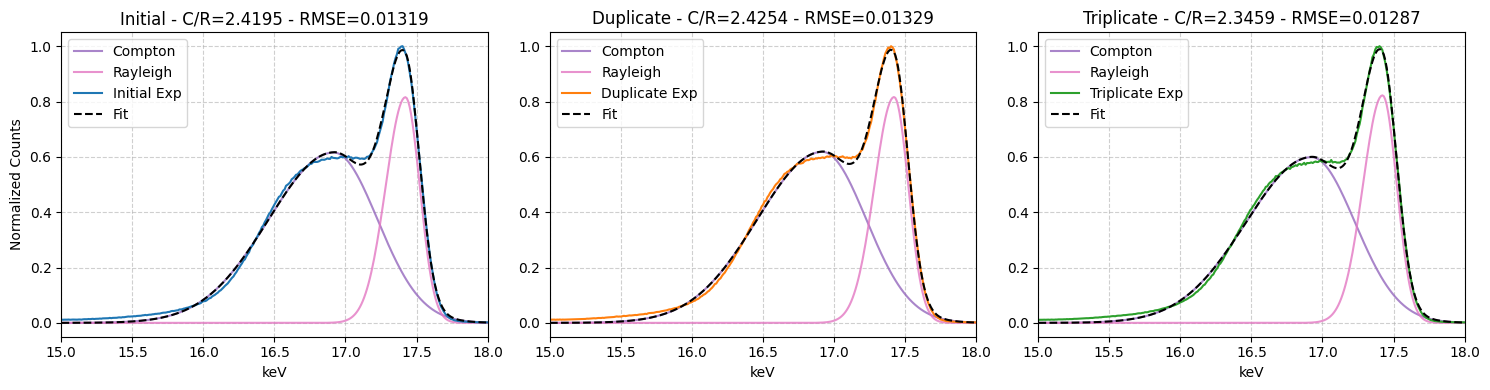

In [8]:
# Plotting
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].plot(energy, split_compton(energy, *params_ini[:4]), label="Compton", color="tab:purple", alpha=0.8)
axs[0].plot(energy, split_rayleigh(energy, *params_ini[4:]), label="Rayleigh", color="tab:pink", alpha=0.8)
axs[0].plot(energy, countsNorm, color='tab:blue', label='Initial Exp')
axs[0].plot(energy, func_ini(energy, *params_ini), linestyle='--', label="Fit", color="black")
axs[0].set_xlabel('keV')
axs[0].set_ylabel('Normalized Counts')
axs[0].set_title(f'Initial - C/R={CR_ini:.4f} - RMSE={rmse_ini:.5f}')
axs[0].set_xlim(15,18)

axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend(loc=0)

axs[1].plot(energy_dup, split_compton(energy_dup, *params_dup[:4]), label="Compton", color="tab:purple", alpha=0.8)
axs[1].plot(energy_dup, split_rayleigh(energy_dup, *params_dup[4:]), label="Rayleigh", color="tab:pink", alpha=0.8)
axs[1].plot(energy_dup, countsNorm_dup, color='tab:orange', label='Duplicate Exp')
axs[1].plot(energy_dup, func_dup(energy_dup, *params_dup), linestyle='--', label="Fit", color="black")
axs[1].set_xlabel('keV')
#axs[1].set_ylabel('Normalized Counts')
axs[1].set_title(f'Duplicate - C/R={CR_dup:.4f} - RMSE={rmse_dup:.5f}')
axs[1].set_xlim(15,18)

axs[1].grid(True, linestyle='--', alpha=0.6)
axs[1].legend(loc=0)

axs[2].plot(energy_tri, split_compton(energy_tri, *params_tri[:4]), label="Compton", color="tab:purple", alpha=0.8)
axs[2].plot(energy_tri, split_rayleigh(energy_tri, *params_tri[4:]), label="Rayleigh", color="tab:pink", alpha=0.8)
axs[2].plot(energy_tri, countsNorm_tri, color='tab:green', label='Triplicate Exp')
axs[2].plot(energy_tri, func_tri(energy_tri, *params_tri), linestyle='--', label="Fit", color="black")
axs[2].set_xlabel('keV')
#axs[1].set_ylabel('Normalized Counts')
axs[2].set_title(f'Triplicate - C/R={CR_tri:.4f} - RMSE={rmse_tri:.5f}')
axs[2].set_xlim(15,18)

axs[2].grid(True, linestyle='--', alpha=0.6)
axs[2].legend(loc=0)

plt.tight_layout()

plt.savefig(f'{name_base}_Plot_Fit.png', dpi=300, bbox_inches='tight')

plt.show()

In [9]:
# Sheet: {name_base} Summary
summary = [
    {
        "Name": f"{name_base}_initial",
        "a1": params_ini[0], "b1": params_ini[1], "sigma1_left": params_ini[2], "sigma1_right": params_ini[3],
        "a2": params_ini[4], "b2": params_ini[5], "sigma2_left": params_ini[6], "sigma2_right": params_ini[7],
        "Compton Area": areaC_ini, "Rayleigh Area": areaR_ini, "Ratio C/R": CR_ini, "MSE": mse_ini, "RMSE": rmse_ini, "R2": r2_ini
    },
    {
        "Name": f"{name_base}_duplicate",
        "a1": params_dup[0], "b1": params_dup[1], "sigma1_left": params_dup[2], "sigma1_right": params_dup[3],
        "a2": params_dup[4], "b2": params_dup[5], "sigma2_left": params_dup[6], "sigma2_right": params_dup[7],
        "Compton Area": areaC_dup, "Rayleigh Area": areaR_dup, "Ratio C/R": CR_dup, "MSE": mse_dup, "RMSE": rmse_dup, "R2": r2_dup
    },
    {
        "Name": f"{name_base}_triplicate",
        "a1": params_tri[0], "b1": params_tri[1], "sigma1_left": params_tri[2], "sigma1_right": params_tri[3],
        "a2": params_tri[4], "b2": params_tri[5], "sigma2_left": params_tri[6], "sigma2_right": params_tri[7],
        "Compton Area": areaC_tri, "Rayleigh Area": areaR_tri, "Ratio C/R": CR_tri, "MSE": mse_tri, "RMSE": rmse_tri, "R2": r2_tri
    }
]

# Sheet: {name_base} Initial
initialEnergy = energy # Column: Energy keV
initialCompton = split_compton(energy, *params_ini[:4]) # Column: Compton
initialRayleigh = split_rayleigh(energy, *params_ini[4:]) # Column: Rayleigh
initialFit = func_ini(energy, *params_ini) # Column: Fit
initialCountsNorm = countsNorm # Column: Normalized Experimental Counts

# Sheet: {name_base} Duplicate
duplicateEnergy = energy_dup # Column: Energy keV
duplicateCompton = split_compton(energy_dup, *params_dup[:4]) # Column: Compton
duplicateRayleigh = split_rayleigh(energy_dup, *params_dup[4:]) # Column: Rayleigh
duplicateFit = func_dup(energy_dup, *params_dup) # Column: Fit
duplicateCountsNorm = countsNorm_dup # Column: Normalized Experimental Counts

# Sheet: {name_base} Triplicate
triplicateEnergy = energy_tri # Column: Energy keV
triplicateCompton = split_compton(energy_tri, *params_tri[:4]) # Column: Compton
triplicateRayleigh = split_rayleigh(energy_tri, *params_tri[4:]) # Column: Rayleigh
triplicateFit = func_dup(energy_tri, *params_tri) # Column: Fit
triplicateCountsNorm = countsNorm_tri # Column: Normalized Experimental Counts

In [10]:
df_summary = pd.DataFrame(summary)

df_initial = pd.DataFrame({
    'Energy keV': initialEnergy,
    'Compton': initialCompton,
    'Rayleigh': initialRayleigh,
    'Fit': initialFit,
    'Norm. Exp.': initialCountsNorm
})

df_duplicate = pd.DataFrame({
    'Energy keV': duplicateEnergy,
    'Compton': duplicateCompton,
    'Rayleigh': duplicateRayleigh,
    'Fit': duplicateFit,
    'Norm. Exp.': duplicateCountsNorm
})

df_triplicate = pd.DataFrame({
    'Energy keV': triplicateEnergy,
    'Compton': triplicateCompton,
    'Rayleigh': triplicateRayleigh,
    'Fit': triplicateFit,
    'Norm. Exp.': triplicateCountsNorm
})

file_name = f"{name_base}_results.xlsx"

with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
    df_summary.to_excel(writer, sheet_name=f'Summary {name_base}', index=False)
    df_initial.to_excel(writer, sheet_name='Initial', index=False)
    df_duplicate.to_excel(writer, sheet_name='Duplicate', index=False)
    df_triplicate.to_excel(writer, sheet_name='Triplicate', index=False)